In [1]:
import numpy as np
from ugme_software import UGME
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 16
plt.rcParams['font.family'] = 'serif'

In [16]:
dt = 1.0
model = UGME(dt=0.1).fit_fetch("badskm.npy")
assert model.check_initial_U()
assert np.allclose(model.tpm, model.reconstruct_tpm())

In [17]:
# get TPMs and corresponding Ut
TPMs = model.tpm
Ut = model.U

# time axis
tsteps, dim, _ = TPMs.shape
time_axis = np.arange(0, tsteps, 1) * dt

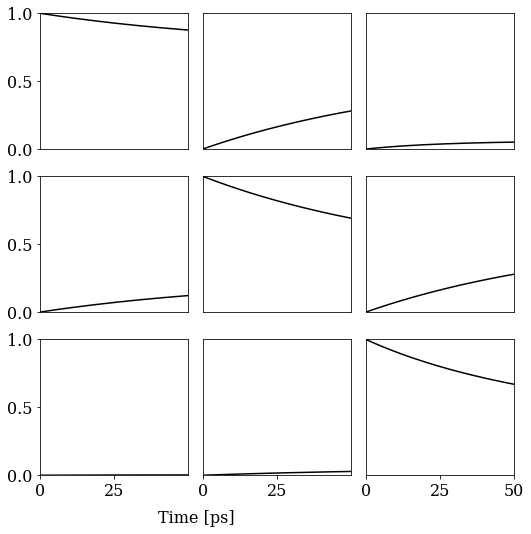

In [18]:
fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(nrows=dim, ncols=dim)
num_rows = dim
xlb = 0
xub = 50
xmb = xub//2

ylb = 0
ymb = 0.5
yub = 1
scale = 1

for i in range(dim):
    for j in range(dim):
        subplot_number = num_rows * i + j + 1
        plt.subplot(num_rows, num_rows, subplot_number)
        #Clabel = "$\mathcal{C}$" + f"$_{i+1}$" + f"$_{j+1}$"
        plt.plot(time_axis, TPMs[:, i, j], color="black",
                 mfc="None", marker=' ', markersize=8, markevery=200, ls="-")

        plt.xticks([])
        plt.yticks([])
        plt.ylim(ylb, yub)
        plt.xlim(xlb, xub)
        #plt.text(3000, 0.85, "$\mathcal{C}$" + f"$_{i+1}$" + f"$_{j+1}$", fontsize=20)

        if i == dim-1:
            plt.xticks([xlb, xmb, xub])
        if j == 0:
            plt.yticks([ylb, ymb, yub])
        if i == 5 and j == 1:
            plt.xlabel("Time [ps]", labelpad=10)
        if i == dim-1 and j != dim-1:
            plt.xticks([xlb, xmb])
        #if i == 1 and j == 0:
            #plt.ylabel("$\mathcal{C}(t)$", labelpad=10)
        #plt.legend(loc="upper right", frameon=False, borderpad=0, handlelength=1)

space_param = 0.1
plt.subplots_adjust(wspace=space_param, hspace=space_param+0.1)
plt.text(-70, -0.35, "Time [ps]")
#if 0: plt.savefig("figs/a2p_full_TPMS.pdf", transparent=True, dpi=600, bbox_inches='tight')
plt.show()

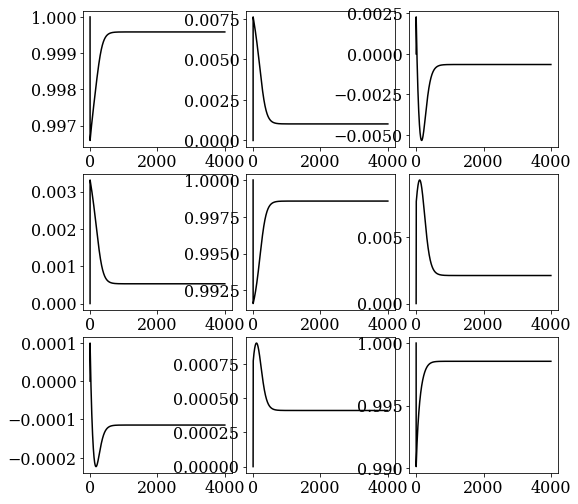

In [19]:
fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(nrows=dim, ncols=dim)
num_rows = dim
xlb = 0
xub = 50
xmb = xub//2

ylb = 0
ymb = 0.5
yub = 1
scale = 1

for i in range(dim):
    for j in range(dim):
        subplot_number = num_rows * i + j + 1
        plt.subplot(num_rows, num_rows, subplot_number)
        plt.plot(time_axis, Ut[:, i, j], color="black",
                 mfc="None", marker=' ', markersize=8, markevery=200, ls="-")

space_param = 0.1
plt.subplots_adjust(wspace=space_param, hspace=space_param+0.1)
#plt.text(-70, -0.35, "Time [ps]")
#if 0: plt.savefig("figs/a2p_full_TPMS.pdf", transparent=True, dpi=600, bbox_inches='tight')
plt.show()

In [25]:
tR_list = np.arange(1, 1000, 20)
rmses = model.scan_rmse(tR_list)

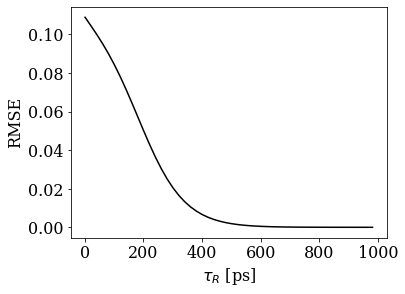

In [26]:
fig, ax = plt.subplots(figsize=(8.5/1.5, 8.5/2))
plt.plot(tR_list*dt, rmses, c="black")
plt.ylabel("RMSE")
plt.xlabel(r"$\tau_R$ [ps]")
plt.show()

In [27]:
tr_list    = np.arange(0, 40)
tauR_list  = np.arange(1, min(40, model.n_steps))

# initialize grid with nans, so that they don't appear in triangle heat map
rmse_grid = np.full((tr_list.size, tauR_list.size), np.nan)
for i, t_r in enumerate(tr_list):
    for j, tau_R in enumerate(tauR_list):
        if tau_R > t_r:
            rmse_grid[i, j] = model.rmse_averaged(int(t_r), int(tau_R))

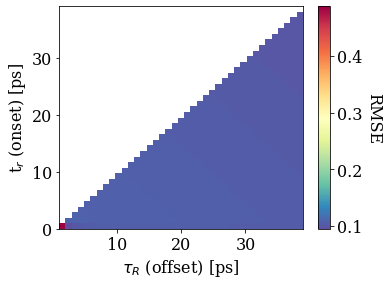

In [28]:
fig, ax = plt.subplots(figsize=(8.5/1.5, 8.5/2))

im = ax.imshow(
    rmse_grid,
    origin="lower",
    aspect="auto",
    cmap="Spectral_r",
    extent=[tauR_list[0]*dt, tauR_list[-1]*dt,
            tr_list[0]*dt,   tr_list[-1]*dt],
)

ax.set_xlabel(r"$\tau_R$ (offset) [ps]")
ax.set_ylabel(r"t$_r$ (onset) [ps]")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('RMSE', rotation=-90, labelpad=20)
fig.tight_layout()
plt.show()

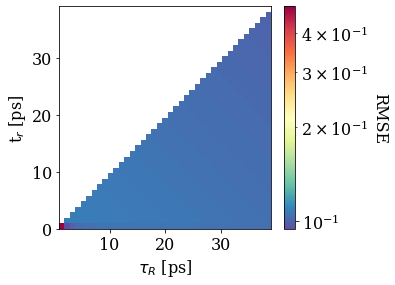

In [29]:
# same thing with log norm
from matplotlib.colors import LogNorm 
fig, ax = plt.subplots(figsize=(8.5/1.5, 8.5/2))

im = ax.imshow(
    rmse_grid,
    origin="lower",
    aspect="auto",
    cmap="Spectral_r",
    norm=LogNorm(vmin=np.nanmin(rmse_grid), vmax=np.nanmax(rmse_grid)),
    extent=[tauR_list[0]*dt, tauR_list[-1]*dt,
            tr_list[0]*dt,   tr_list[-1]*dt],
)

ax.set_xlabel(r"$\tau_R$ [ps]")
ax.set_ylabel(r"t$_r$ [ps]")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('RMSE', rotation=-90, labelpad=20)
fig.tight_layout()
plt.show()

# Show what U(t) looks like

In [32]:
tau_R = 800
prediction = model.predict(tau_R)
print(model.rmse(tau_R))

U_inf = model.U[tau_R]
U_with_tau_R = model.U.copy()
U_with_tau_R[tau_R:] = U_inf

3.215500118281049e-05


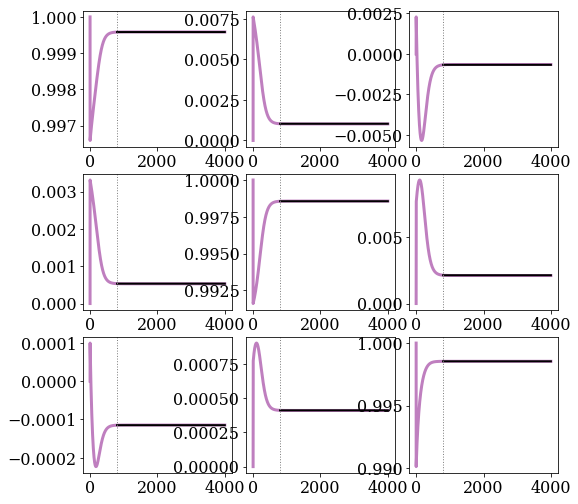

In [33]:
fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(nrows=dim, ncols=dim)
space_param = 0.25
num_rows = dim
xlb = 0
xub = 50
xmb = xub//2

ylb = 0
ymb = 0.5
yub = 1
scale = 1

for i in range(dim):
    for j in range(dim):
        subplot_number = num_rows * i + j + 1
        plt.subplot(num_rows, num_rows, subplot_number)
        plt.plot(time_axis, Ut[:, i, j], color="purple", ls="-", alpha=0.5, lw=3)
        plt.plot(time_axis[tau_R:], U_with_tau_R[tau_R:, i, j], color="black", ls="-", alpha=1, lw=2)
        plt.axvline(tau_R * dt, color="gray", ls=":", lw=1)

space_param = 0.1
plt.subplots_adjust(wspace=space_param, hspace=space_param+0.1)
#plt.text(-70, -0.35, "Time [ps]")
#if 0: plt.savefig("figs/a2p_full_TPMS.pdf", transparent=True, dpi=600, bbox_inches='tight')
plt.show()

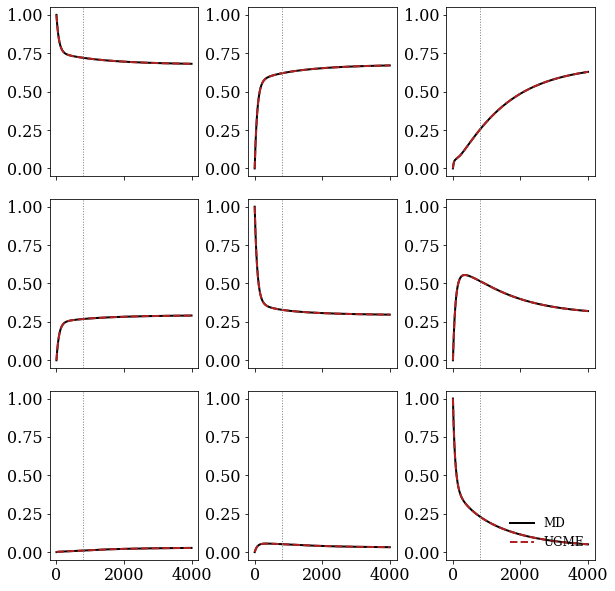

In [38]:
tau_R = 800
pred = model.predict(tau_R)
ref  = model.tpm

space_param = 0.25
fig, axes = plt.subplots(dim, dim, figsize=(8.5, 8.5), sharex=True)
plt.subplots_adjust(wspace=space_param, hspace=space_param+0.1)
for i in range(dim):
    for j in range(dim):
        ax = axes[i, j]
        ax.plot(time_axis[:ref.shape[0]], ref[:, i, j], "black",lw=2, label="MD")
        ax.plot(time_axis, pred[:, i, j], "firebrick", lw=2, ls="--", label="UGME")
        ax.axvline(tau_R * dt, color="gray", ls=":", lw=1)
        ax.set_ylim(-0.05, 1.05)
axes[dim-1, dim-1].legend(fontsize=12, frameon=False, loc="lower right")

#fig.suptitle(rf"U-GME prediction at $\tau_R$ = {tau_R}")
fig.tight_layout()
plt.show()